### How much faster is it to compute modes using Cholesky instead of LU decomposition?

By default, `EigenSolver.solve()` uses `decomp='lu'`, which relies on `scipy`'s LU decomposition of
the sparse shift-invert matrix `stiffness - sigma * mass` into `L @ U`, where `L` and `U` are lower
and upper triangular square matrices, respectively. The shift-invert method of solving the
generalized eigenvalue problem provides computational efficiency by sequentially solving for modes
whose eigenvalues are closest to `sigma`. For `sigma` < 0 (default), the shift-invert matrix is
symmetric positive definite, meaning that a Cholesky decomposition can be used instead (`L_chol @
L_chol.T`, where `L_chol` is a lower triangular matrix). According to *Numerical Recipes in C: The
Art of Scientific Computing (1992)*, Cholesky decomposition is roughly twice as efficient as LU
decomposition for solving linear systems. Here, passing `decomp='cholesky'` to `EigenSolver.solve()`
will attempt to import and use the `cholespy` package, which is an optional dependency
(`neuromodes[cholesky]`). This package binds the SuiteSparse library written in C, containing
CHOLMOD for sparse Cholesky decomposition. It has no subdependencies and circumnavigates challenges
with installing SuiteSparse via `scikit-sparse`, as is supported optionally by LaPy
(`lapy.solver.Solver.eigs(use_cholmod=True)`).

In this notebook, we assess the speed advantage conferred by Cholesky decomposition for the fsLR-32k
surface across different `n_modes`. We find that Cholesky decomposition is ~2x faster for low
`n_modes`, but can be only ~1.3% faster for higher `n_modes`.

In [1]:
from time import time

import matplotlib.pyplot as plt
import numpy as np

from neuromodes import EigenSolver
from neuromodes.io import fetch_example_surf


In [2]:
surf, medmask = fetch_example_surf()
solver = EigenSolver(surf, medmask).compute_lbo()

In [ ]:
n_modes_vals = [1, 5, 10, 50, 100, 500, 1000]
decomp_methods = ['lu', 'cholesky']

# TODO: consider averaging over multiple runs to reduce noise in timing results
times = np.empty((len(n_modes_vals), len(decomp_methods)))
for i, n_modes in enumerate(n_modes_vals):
    for j, decomp in enumerate(decomp_methods):
        t0 = time()
        solver.solve(n_modes, decomp=decomp, seed=0)
        t1 = time()
        print(f'Computed {n_modes} modes using {decomp} decomposition in {t1-t0} seconds')
        times[i, j] = t1-t0

Computed 1 modes using lu decomposition in 1.6225166320800781 seconds
Computed 1 modes using cholesky decomposition in 0.8311212062835693 seconds
Computed 5 modes using lu decomposition in 2.097273111343384 seconds
Computed 5 modes using cholesky decomposition in 1.0555915832519531 seconds
Computed 10 modes using lu decomposition in 2.1829020977020264 seconds
Computed 10 modes using cholesky decomposition in 1.1839139461517334 seconds
Computed 50 modes using lu decomposition in 3.4962658882141113 seconds
Computed 50 modes using cholesky decomposition in 1.958453893661499 seconds
Computed 100 modes using lu decomposition in 5.61037540435791 seconds
Computed 100 modes using cholesky decomposition in 3.2095654010772705 seconds
Computed 500 modes using lu decomposition in 39.40968132019043 seconds
Computed 500 modes using cholesky decomposition in 30.428050994873047 seconds
Computed 1000 modes using lu decomposition in 179.45364618301392 seconds
Computed 1000 modes using cholesky decomposi

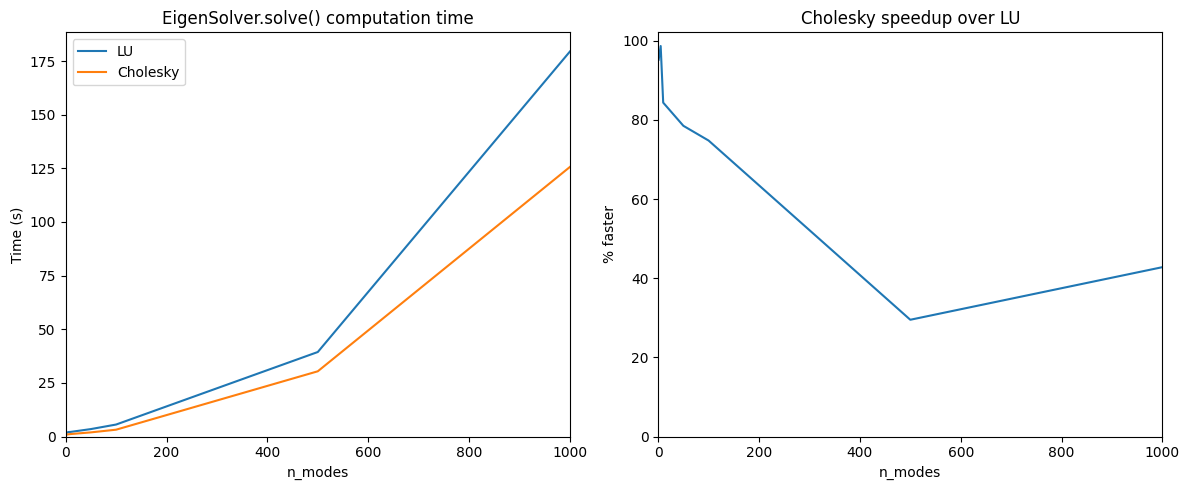

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(n_modes_vals, times[:, 0], label='LU')
axs[0].plot(n_modes_vals, times[:, 1], label='Cholesky')
axs[0].set_xlabel('n_modes')
axs[0].set_ylabel('Time (s)')
axs[0].set_title('EigenSolver.solve() computation time')
axs[0].legend()
axs[0].set_xlim(0, n_modes_vals[-1])
axs[0].set_ylim(bottom=0)

perc_faster = (times[:, 0] - times[:, 1]) / times[:, 1] * 100
axs[1].plot(n_modes_vals, perc_faster)
axs[1].set_xlabel('n_modes')
axs[1].set_ylabel('% faster')
axs[1].set_title('Cholesky speedup over LU')
axs[1].set_xlim(0, n_modes_vals[-1])
axs[1].set_ylim(bottom=0)
plt.tight_layout()
plt.show()